In [2]:
import os
import math
import pickle
import xarray as xr
import datetime
from tqdm import tqdm
from netCDF4 import Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cartopy 
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import matplotlib.colors as mcolors

####   setup

In [3]:
# Target grid resolusion
res_TarGrid = '44'
dir_d = '/glade/campaign/mmm/c3we/mingge/FRONTIERS/OBJS/Regular_0.' + res_TarGrid+'/'

dir_cerra = dir_d + 'CERRA/'
 
# OLD dir_o = '/glade/campaign/mmm/c3we/mingge/FRONTIERS/'
dir_o = '/glade/campaign/mmm/c3we/mingge/FRONTIERS/PAPER/'

# for CERRA
year_s = 1990
year_e = 2010
n_year = year_e - year_s + 1

flnm = dir_cerra + '201001_CERRA_ObjectMasks__dt-3h_MOAAP-masks.nc'

ncid = Dataset(flnm)
Lat = np.squeeze(ncid.variables['lat'][:])
Lon = np.squeeze(ncid.variables['lon'][:])
nx = Lon.shape[0]
ny = Lon.shape[1]
ncid.close()
print('Lat Lon grid is from ', flnm, nx, ny)

lat_1d = Lat[:,0]
lon_1d = Lon[0]

n_lon = len(lon_1d)
n_lat = len(lat_1d)

Lat Lon grid is from  /glade/campaign/mmm/c3we/mingge/FRONTIERS/OBJS/Regular_0.44/CERRA/201001_CERRA_ObjectMasks__dt-3h_MOAAP-masks.nc 92 187


#### calculate daily maximum precipitation of each region

['ACY', 'CY', 'CY_z500', 'JET', 'MCS_Tb', 'MS']
0


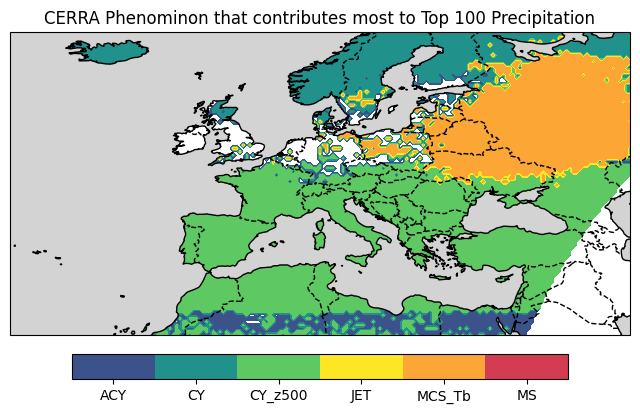

1


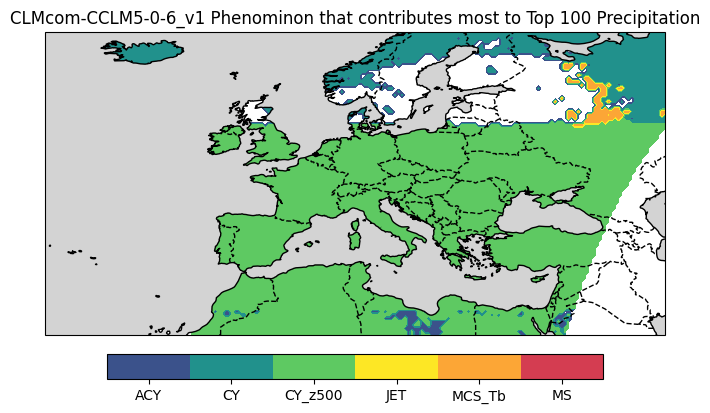

2


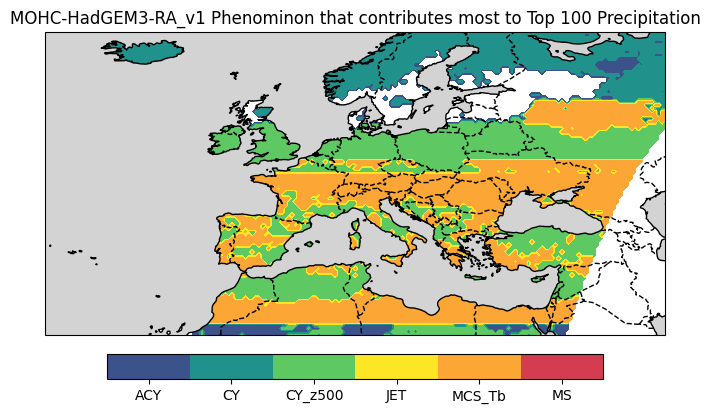

3


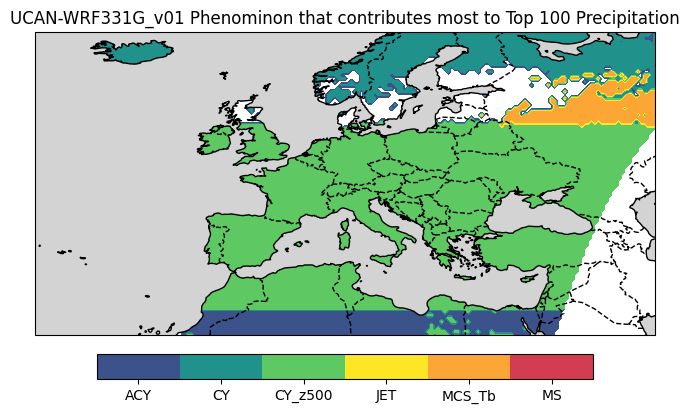

4


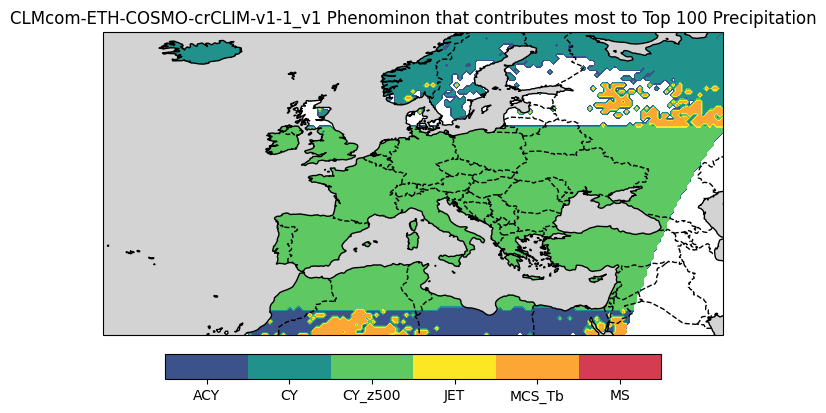

5


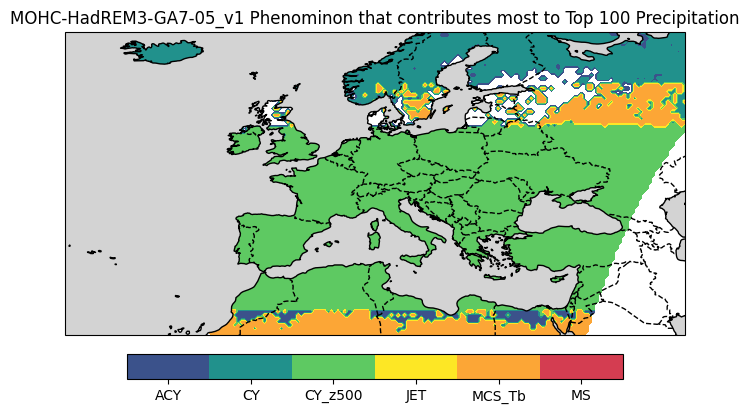

6


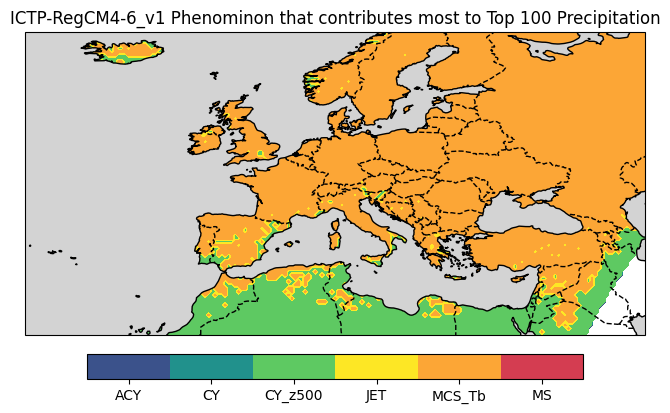

CPU times: user 2.62 s, sys: 91 ms, total: 2.71 s
Wall time: 2.89 s


In [38]:
%%time
from matplotlib.colors import ListedColormap
EUR_1d = ['CERRA', 'EUR-44', 'EUR-11']

# Define 6 distinct colors
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']
# Define 7 specific colors for 7 specific values
colors = ["#3b528b", "#21918c", "#5ec962", "#fde725", "#fca636", "#d43d51"] #, "#9e0142"]
# Define levels corresponding to specific values
levels = [.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]  # Midpoints between values

cmap = ListedColormap(colors)

Categories = [ 'BT', 'ACY', 'CY', 'CY_z500', 'FR', 'JET', 'MCS_Tb', 'MS' ]  
n_cat = len(Categories) 
# We don't need 'BT' and and FR
cat_plot = Categories[1:4] + Categories[5:]
print(cat_plot)

dominant_3d = np.zeros((7, n_lat, n_lon), dtype=int) - 99

ct = 0
for res_EUR in EUR_1d:   
    if res_EUR == 'EUR-44':
        model_s = ['CLMcom-CCLM5-0-6_v1', 
                   'MOHC-HadGEM3-RA_v1', 
                   'UCAN-WRF331G_v01']
    elif res_EUR == 'EUR-11':
        model_s = ['CLMcom-ETH-COSMO-crCLIM-v1-1_v1', \
                'MOHC-HadREM3-GA7-05_v1',\
                'ICTP-RegCM4-6_v1']
    elif res_EUR == 'CERRA':
        model_s = ['CERRA']

    n_model = len(model_s)
     
    for nm in range(n_model):
        is_first = True
        for year in range(year_s, year_e + 1):
            flnm_i = dir_o + "Extr_100_1000.0km-radius_" + \
                 model_s[nm] + '_' + res_EUR + '_' +str(year) +".nc"

            #print('extreme file:', flnm_i)
            
            with xr.open_dataset(flnm_i) as ds:
                data_0 = ds.nFeatures.values
                if is_first == True:
                    data = data_0
                    is_first = False
                else:
                    data = data + data_0
                 
        for nlon in range(n_lon):
            for nlat in range(n_lat):
                # We don't need 'BT':0  and and FR:4
                data_1d = np.r_[data[1:4, nlat, nlon], data[5:, nlat, nlon]]
                         
                if not np.all(data_1d == 0):
                    # Find the Index of the Maximum Value   
                    max_index = np.argmax(data_1d)
                    dominant_3d[ct, nlat, nlon] = max_index 
        ct = ct + 1
        print(ct-1)

        # Plot contourf with 8 colors
        fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': ccrs.PlateCarree()})

        contour = ax.contourf(Lon, Lat, dominant_3d[ct-1], colors=colors,levels=levels)
        ax.coastlines()
        ax.add_feature(cartopy.feature.BORDERS, linestyle='--') 
        ax.add_feature(cfeature.OCEAN, facecolor='lightgray', zorder=1) 
    
        # Add colorbar with custom ticks
        cbar = plt.colorbar(contour, ticks=[ 1, 2, 3, 4, 5, 6], \
                        pad=0.05, # Smaller pad value brings it closer
                        shrink=0.8, orientation='horizontal')
        cbar.set_ticklabels(cat_plot)   

        # Labels and title
        ax.set_title(model_s[nm] + " Phenominon that contributes most to Top 100 Precipitation" )
        plt.show() 